[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AnahitShekikyan/ml-with-python-for-high-school-students/blob/main/chapter_03_data_preparation/chapter_3_2_exploratory_data_analysis.ipynb)

# 📊 Chapter 3.2: Exploratory Data Analysis (EDA)

## What Is EDA?

**Exploratory Data Analysis (EDA)** is the process of visually and statistically exploring a dataset to understand its patterns, relationships, and quirks — **before** building any ML model.

Think of it like getting to know someone before working with them. The better you understand your data, the better your model will be.

> 📌 **Note:** Make sure you've run `chapter_3_1_data_cleaning.ipynb` first — this notebook uses the cleaned dataset (`spotify_tracks_clean.csv`).

---

### 🎯 Learning Goals

| # | Goal |
|---|------|
| 1 | Explore distributions of numeric features |
| 2 | Analyze categorical features with bar charts |
| 3 | Examine correlations between numeric features |
| 4 | Explore patterns related to song popularity |
| 5 | Develop hypotheses about what may influence popularity |

---
## ⚙️ Setup — Import Libraries and Load the Clean Dataset

In this notebook, we will use the cleaned Spotify dataset from Chapter 3.1 to explore distributions, categories, and relationships in the data.

In [ ]:
# importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load the cleaned dataset from chapter 3.1
df = pd.read_csv("spotify_tracks_clean.csv")
print(f"Loaded clean dataset: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Loaded clean dataset: 113550 rows × 20 columns


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,Acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,Acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,Acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,Acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,Acoustic


---
## 3.2.1 Warm-Up 

> 🏋️ **Think about it first:**
>
> 1. What makes a song popular on Spotify? List 3 things you think matter.
> 2. Do you think songs with high **danceability** tend to be more popular? Why?
> 3. Which genre do you think has the highest average popularity?

**✏️ Your answers here:**

1. 

2. 

3. 

---
## 3.2.2 Numeric Distributions 📈

A **histogram** shows how values in a column are distributed — are most values clustered in the middle? Skewed to one side? Spread out evenly?

Below are histograms for some of the most important numeric features in the dataset.

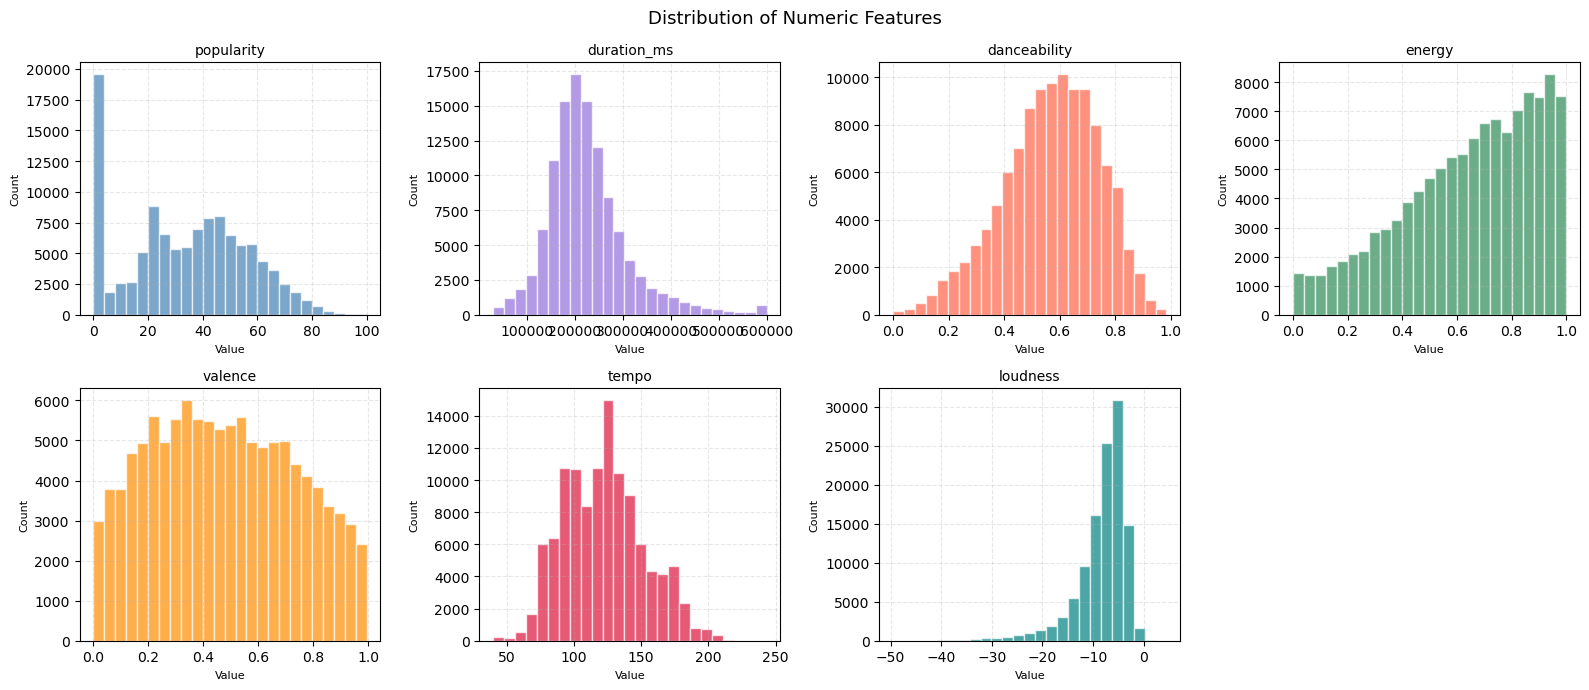

In [20]:
# the most important continuous features (numeric columns) in the dataset
numeric_cols = ['popularity', 'duration_ms', 'danceability', 'energy', 'valence', 'tempo', 'loudness']

# this helps prevent errors if a column name is missing
numeric_cols = [col for col in numeric_cols if col in df.columns]

# create a figure with 2 rows and 4 columns of subplots, this gives us space to plot up to 8 histograms
fig, axes = plt.subplots(2, 4, figsize=(16, 7))

# flatten the subplot grid into a 1D list so it is easier to loop through
axes = axes.flatten()

# assign a different color to each histogram
colors = ['steelblue', 'mediumpurple', 'tomato', 'seagreen', 'darkorange', 'crimson', 'teal']

# loop through each selected numeric column and plot its histogram
for i, (col, color) in enumerate(zip(numeric_cols, colors)):
    # remove missing values so they do not affect the plot
    axes[i].hist(df[col].dropna(), bins=25, color=color, alpha=0.7, edgecolor='white')
    
    # add a title and axis labels for clarity
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Value', fontsize=8)
    axes[i].set_ylabel('Count', fontsize=8)
    
    # add light grid lines to make the distribution easier to read
    axes[i].grid(True, linestyle='--', alpha=0.3)

# hide any extra subplot boxes if we have fewer than 8 histograms
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

# add one overall title for the full figure
plt.suptitle('Distribution of Numeric Features', fontsize=13)

# adjust spacing so the plots do not overlap
plt.tight_layout()

# display the final figure
plt.show()

> 🏋️ **Practice 1 — Read the Histograms:**
> 1. The `tempo` distribution — is it spread evenly or skewed? What does that tell us?
> 2. The `danceability` distribution — does it look roughly bell-shaped (normal) or skewed?
> 3. The `popularity` distribution — are most songs very popular, average, or unpopular?

**✏️ Your answers here:**

1. 

2. 

3. 

---
## 3.2.3 Categorical Features 🎸

**Bar charts** show how many songs belong to each category — like how many songs are in each genre.

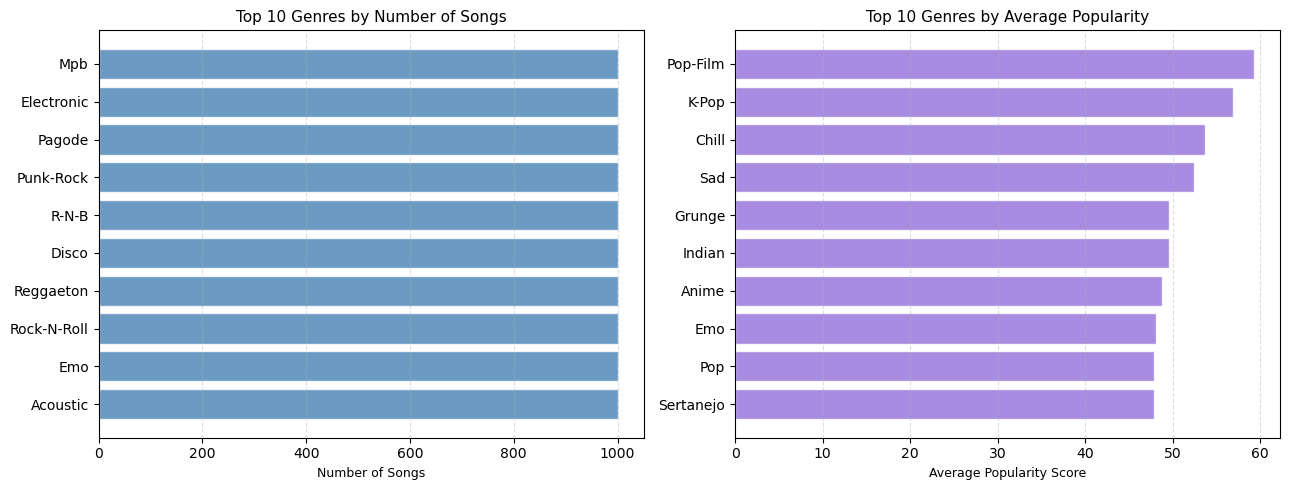

In [21]:
# Create a figure with 1 row and 2 columns of subplots
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Count how many songs belong to each genre
genre_counts = df['track_genre'].value_counts().head(10)

# Plot the top 10 genres by number of songs
axes[0].barh(
    genre_counts.index,
    genre_counts.values,
    color='steelblue',
    alpha=0.8,
    edgecolor='white'
)
axes[0].set_title('Top 10 Genres by Number of Songs', fontsize=11)
axes[0].set_xlabel('Number of Songs', fontsize=9)
axes[0].grid(True, axis='x', linestyle='--', alpha=0.4)

# Calculate average popularity for each genre
avg_pop = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False).head(10)

# Sort the values again so the horizontal bar chart is easier to read
avg_pop = avg_pop.sort_values()

# Plot the top 10 genres by average popularity
axes[1].barh(
    avg_pop.index,
    avg_pop.values,
    color='mediumpurple',
    alpha=0.8,
    edgecolor='white'
)
axes[1].set_title('Top 10 Genres by Average Popularity', fontsize=11)
axes[1].set_xlabel('Average Popularity Score', fontsize=9)
axes[1].grid(True, axis='x', linestyle='--', alpha=0.4)

# Adjust spacing so the plots do not overlap
plt.tight_layout()

# Show the final figure
plt.show()

### Explicit vs Non-Explicit Songs

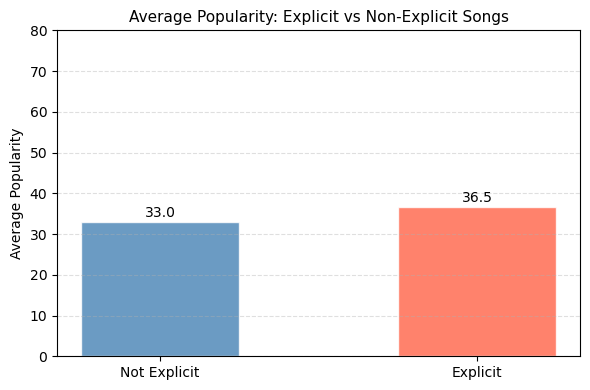

In [23]:
# calculate average popularity for explicit and non-explicit songs
explicit_pop = df.groupby('explicit')['popularity'].mean()

# create a bar chart
plt.figure(figsize=(6, 4))
bars = plt.bar(
    ['Not Explicit', 'Explicit'],
    [explicit_pop.get(False, 0), explicit_pop.get(True, 0)],
    color=['steelblue', 'tomato'],
    alpha=0.8,
    edgecolor='white',
    width=0.5
)

# add the value labels above the bars
for bar, val in zip(bars, [explicit_pop.get(False, 0), explicit_pop.get(True, 0)]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{val:.1f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

# add titles and labels
plt.title('Average Popularity: Explicit vs Non-Explicit Songs', fontsize=11)
plt.ylabel('Average Popularity', fontsize=10)
plt.ylim(0, 80)
plt.grid(True, axis='y', linestyle='--', alpha=0.4)

# show the chart
plt.tight_layout()
plt.show()

> 🏋️ **Practice 2:**
> 1. Which genre has the **most songs** among the genres shown?
> 2. Which genre has the **highest average popularity**? Does that surprise you?
> 3. Are explicit songs more or less popular than non-explicit songs in this dataset?

**✏️ Your answers here:**

1. 

2. 

3. 

---
## 3.2.4 Correlation — Which Features Are Related? 

**Correlation** measures how strongly two numeric columns move together:

```
   +1.0  → Perfect positive relationship (as X goes up, Y goes up)
    0.0  → No relationship at all
   -1.0  → Perfect negative relationship (as X goes up, Y goes down)
```

A **correlation heatmap** shows all correlations at once — darker/stronger colors = stronger relationship.

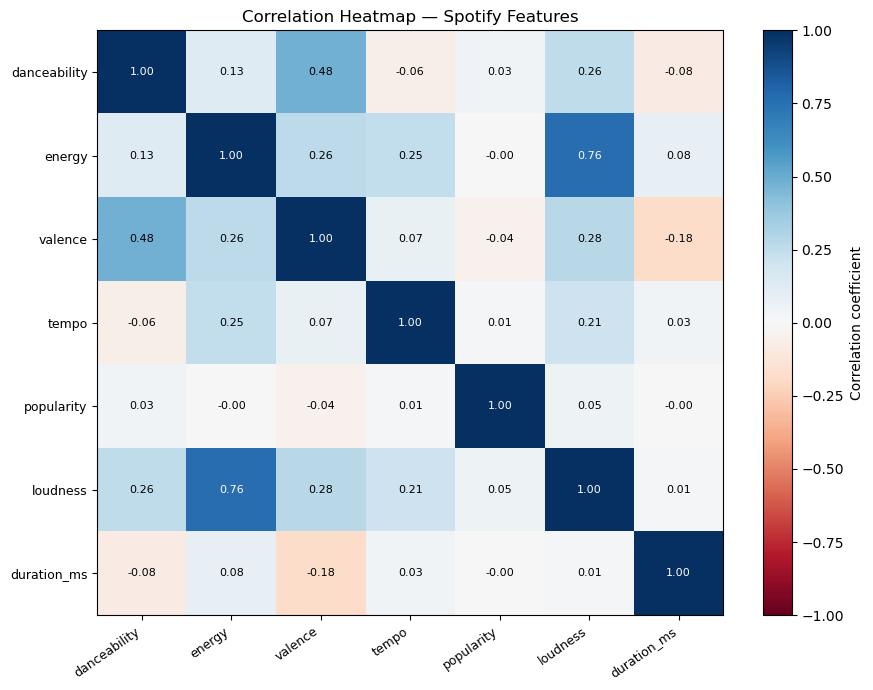

In [33]:
# choose numeric columns for correlation analysis
corr_cols = ['danceability', 'energy', 'valence', 'tempo', 'popularity', 'loudness', 'duration_ms']

# keep only columns that actually exist in the dataset
corr_cols = [col for col in corr_cols if col in df.columns]

# compute the correlation matrix
corr_matrix = df[corr_cols].corr()

# create the heatmap
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix.values, cmap='RdBu', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Correlation coefficient')

# label the axes
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=35, ha='right', fontsize=9)
ax.set_yticklabels(corr_cols, fontsize=9)

# add the correlation value inside each cell
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        val = corr_matrix.values[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8, color=color)

ax.set_title('Correlation Heatmap — Spotify Features', fontsize=12)
plt.tight_layout()
plt.show()

> 🏋️ **Practice 3 — Read the Correlation Heatmap:**
> 1. Which feature has the **strongest positive correlation** with popularity?
> 2. Which two features are most **correlated with each other** (besides a feature with itself)?
> 3. The correlation values are all relatively small (close to 0). What does that tell us about predicting popularity?

**✏️ Your answers here:**

1. 

2. 

3. 

## 3.2.5 Feature Relationships with Popularity

Scatter plots helps to see whether one feature seems related to popularity.

When a dataset is very large, scatter plots can become crowded and difficult to read.  
Lets first look at the full dataset, then create a cleaner sampled version to make the pattern easier to see.

### Full Dataset Scatter Plots

These scatter plots use the full dataset. Notice that with many points, the plots can look dense and harder to interpret.

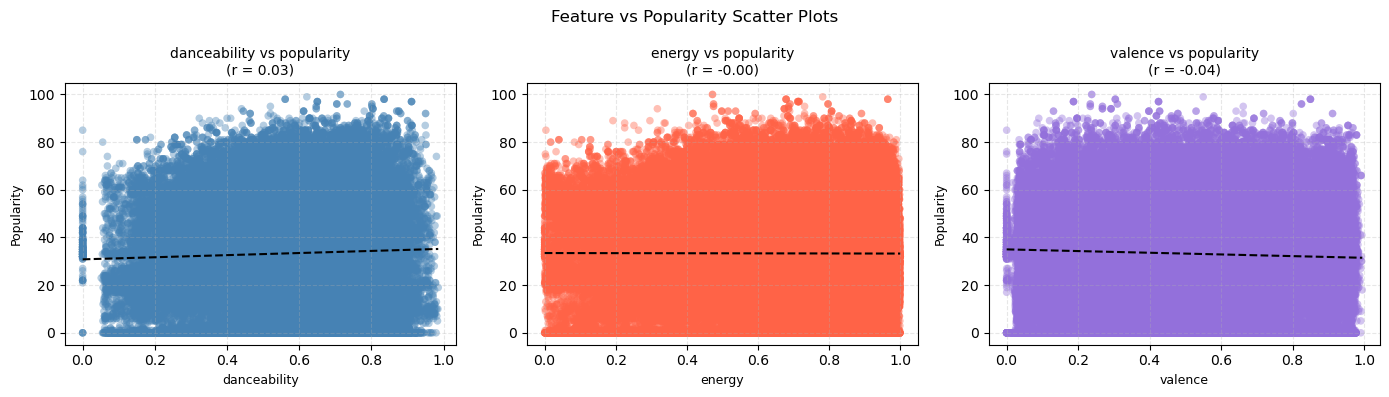

In [26]:
# scatter plots: selected features vs popularity
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

pairs = [
    ('danceability', 'steelblue'),
    ('energy', 'tomato'),
    ('valence', 'mediumpurple')
]

for ax, (feature, color) in zip(axes, pairs):
    # plot the scatter points
    ax.scatter(
        df[feature],
        df['popularity'],
        color=color,
        alpha=0.4,
        s=30,
        edgecolors='none'
    )

    # create a trend line
    x = df[feature].dropna()
    y = df.loc[df[feature].notna(), 'popularity']
    m, b = np.polyfit(x, y, 1)

    x_line = np.linspace(df[feature].min(), df[feature].max(), 100)
    ax.plot(x_line, m * x_line + b, 'k--', linewidth=1.5)

    # calculate correlation for the title
    corr_val = df[[feature, 'popularity']].corr().iloc[0, 1]

    ax.set_title(f'{feature} vs popularity\n(r = {corr_val:.2f})', fontsize=10)
    ax.set_xlabel(feature, fontsize=9)
    ax.set_ylabel('Popularity', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.3)

plt.suptitle('Feature vs Popularity Scatter Plots', fontsize=12)
plt.tight_layout()
plt.show()

### Sampled Scatter Plots

Now lets use a sample of the data to make the scatter plots easier to read.  
Sampling can help reveal patterns more clearly when the full dataset is very crowded.

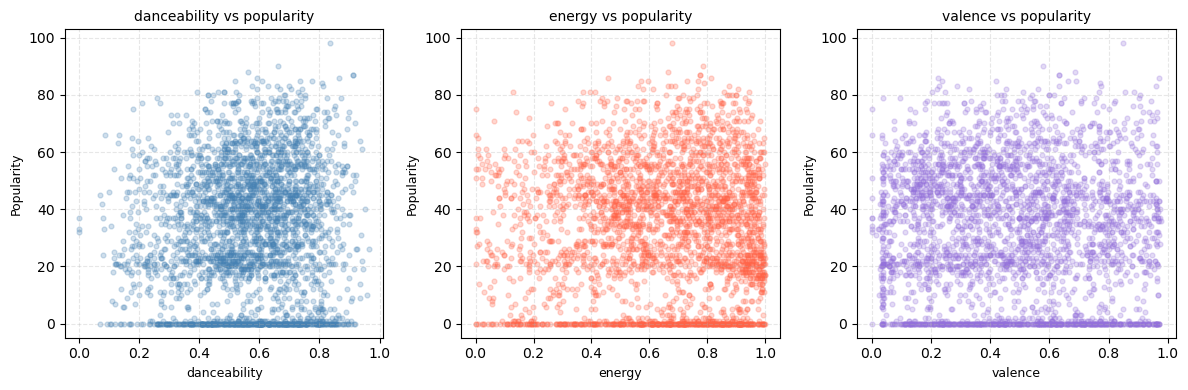

In [ ]:
# the sample of the dataset to reduce overcrowding
sample_df = df.sample(3000, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

pairs = [
    ('danceability', 'steelblue'),
    ('energy', 'tomato'),
    ('valence', 'mediumpurple')
]

for ax, (feature, color) in zip(axes, pairs):
    ax.scatter(sample_df[feature], sample_df['popularity'], color=color, alpha=0.25, s=12)
    ax.set_title(f'{feature} vs popularity', fontsize=10)
    ax.set_xlabel(feature, fontsize=9)
    ax.set_ylabel('Popularity', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

> 🏋️ **Practice 4 — Feature Relationships:**
> 1. Which feature seems to have the strongest relationship with popularity?
> 2. Which feature seems to have the weakest relationship with popularity?
> 3. Based on the plots, do you think popularity can be predicted well using only one feature?

**✏️ Your answers here:**

1. 

2. 

3. 

---
## 3.2.6 Top Artists by Average Popularity 🎤

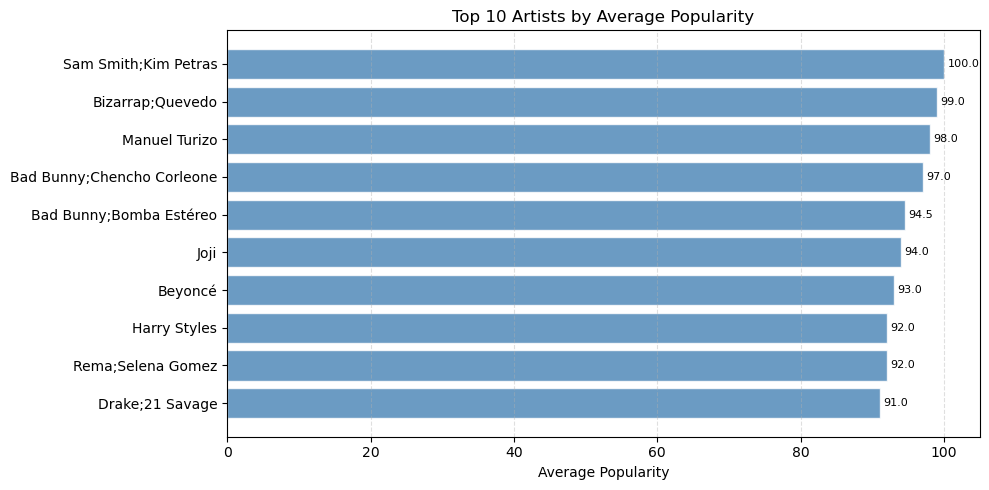

In [30]:
# the average popularity score for each artist
top_artists = df.groupby('artists')['popularity'].mean().sort_values(ascending=False).head(10)

# horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    top_artists.index[::-1],
    top_artists.values[::-1],
    color='steelblue',
    alpha=0.8,
    edgecolor='white'
)

# add the popularity value next to each bar
for bar, val in zip(bars, top_artists.values[::-1]):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}',
        va='center',
        fontsize=8
    )

ax.set_title('Top 10 Artists by Average Popularity', fontsize=12)
ax.set_xlabel('Average Popularity', fontsize=10)
ax.grid(True, axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

> 🏋️ **Practice 5:**
> 1. Which artist has the highest average popularity in the chart?
> 2. Do any artists surprise you in the top 10?
> 3. Why might average popularity be a useful measure, but not a perfect one?

**✏️ Your answers here:**

1. 

2. 

3. 

---
## 3.2.7 Extension Activity 🚀

**Option A:** Create a bar chart showing the **average danceability per genre**. Which genre is the most danceable?

**Option B:** Find the **top 5 most popular songs** in the dataset. Do any of them surprise you?

**Option C:** Create a scatter plot of `tempo` vs `energy`. Do faster-tempo songs tend to have more energy?

In [ ]:
# Option A — your code here!


In [ ]:
# Option B — your code here!


In [ ]:
# Option C — your code here!


---
## ✏️ Finish This Sentence

**From the EDA, the most interesting thing I discovered was...**

*(Write your answer here)*

---
## 🎉 Chapter 3.2 Summary

| Tool | What It Reveals |
|------|------------------|
| **Histogram** | How values are distributed (skewed? normal? uniform?) |
| **Bar chart** | Counts or averages across categories |
| **Scatter plot** | Relationship between two numeric features |
| **Correlation heatmap** | Strength of relationship between all numeric pairs |

---

### 🏆 Chapter Challenge

Write a short paragraph (3–5 sentences) summarizing what you learned from the EDA:
- What features seem most connected to popularity?
- What surprised you most?
- Which features do you think will be most useful for an ML model?

**✏️ Your EDA summary here:**

